<center>
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/Logos/organization_logo/organization_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>


#### Import the required libraries we need for the lab.


In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [40]:
boston_df=pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv')

#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [41]:
#Display the first 5 rows of the dataset.

boston_df.head(5) #This will display the first 5 rows from the dataset we have pulled from the cloud.


,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [42]:
#Display the data types of each column.

boston_df.dtypes #This will display the data types of each column in the dataset.

Unnamed: 0      int64
CRIM          float64
ZN            float64
INDUS         float64
CHAS          float64
NOX           float64
RM            float64
AGE           float64
DIS           float64
RAD           float64
TAX           float64
PTRATIO       float64
LSTAT         float64
MEDV          float64
dtype: object

In [43]:
#Check for missin values in each column.

boston_df.isnull().sum() #This is_null() function will check for missing values in each column.

#Result : No missing value in the dataset.

Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
LSTAT         0
MEDV          0
dtype: int64

In [44]:
#Check for duplicate rows.

boston_df.duplicated().sum() #This will check for duplicate rows in the dataset.

#Result : No duplicate rows in the dataset.


np.int64(0)

In [45]:
#Display the correlation matrix of the dataset.

corr_matrix = boston_df.corr() 
display(corr_matrix) #This will display the correlation matrix of the dataset.

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
Unnamed: 0,1.000000,0.407407,-0.103393,0.399439,-0.003759,0.398736,-0.079971,0.203784,-0.302211,0.686002,0.666626,0.291074,0.258465,-0.226604
CRIM,0.407407,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
ZN,-0.103393,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
INDUS,0.399439,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
CHAS,-0.003759,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
NOX,0.398736,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
RM,-0.079971,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360
AGE,0.203784,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
DIS,-0.302211,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
RAD,0.686002,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626


In [46]:
#Display descriptive statistics of the dataset.

boston_df.describe().round(2) #This will display the descriptive statistics of the dataset rounding to 2 decimal.

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,252.50,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,12.65,22.53
std,146.21,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,7.14,9.20
min,0.00,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,1.73,5.00
25%,126.25,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,6.95,17.02
50%,252.50,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,11.36,21.20
75%,378.75,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,16.96,25.00
max,505.00,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,37.97,50.00


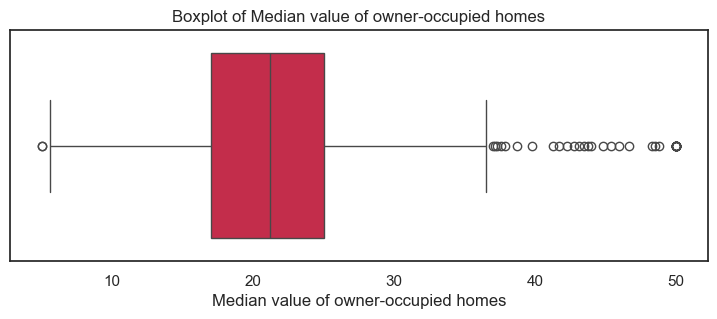

In [47]:
#Create a boxplot for MEDV (Median value of owner-occupied homes).

plt.figure(figsize=(9, 3))
sns.boxplot(x=boston_df['MEDV'],
            color='crimson')
plt.title("Boxplot of Median value of owner-occupied homes")
plt.xlabel("Median value of owner-occupied homes")
plt.show()

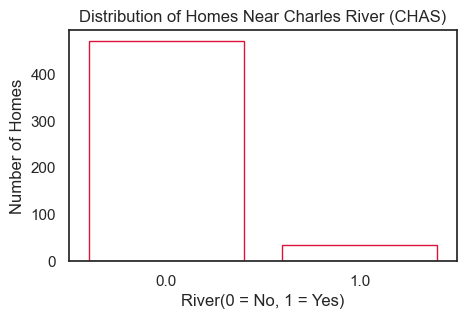

In [48]:
#Create a bar plot for CHAS (Charles River dummy variable).
plt.figure(figsize=(5, 3))
sns.countplot(x=boston_df['CHAS'], color='white', edgecolor='crimson')
plt.title("Distribution of Homes Near Charles River (CHAS)")
plt.xlabel("River(0 = No, 1 = Yes)")
plt.ylabel("Number of Homes")
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_18456\1467418625.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=x, y=boston_df['MEDV'], palette=my_colors)


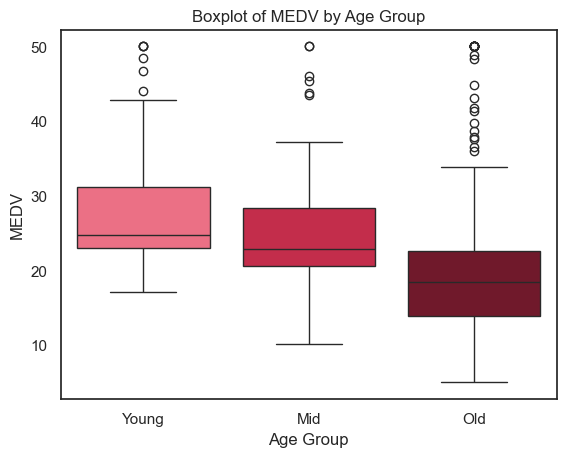

In [51]:
#Discretize AGE into three groups and create a boxplot of MEDV versus these groups:

x = pd.cut(boston_df['AGE'], bins=3, labels=['Young', 'Mid', 'Old'])
my_colors = ["#FF5C77", "#DC143C", "#7E0B22"]

sns.boxplot(x=x, y=boston_df['MEDV'], palette=my_colors)

plt.xlabel("Age Group")
plt.ylabel("MEDV")
plt.title("Boxplot of MEDV by Age Group")

plt.show()


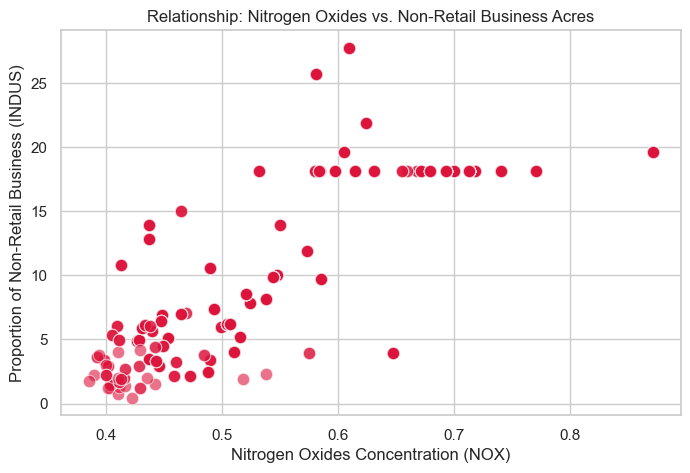

In [52]:
#Create a scatter plot showing the relationship between NOX (nitric oxide concentrations) and INDUS (non-retail business acres).

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    x=boston_df['NOX'], 
    y=boston_df['INDUS'],
    color="crimson",      
    alpha=0.6,             
    edgecolor="white",    
    s=80                   
)
plt.title("Relationship: Nitrogen Oxides vs. Non-Retail Business Acres")
plt.xlabel("Nitrogen Oxides Concentration (NOX)")
plt.ylabel("Proportion of Non-Retail Business (INDUS)")

plt.show()

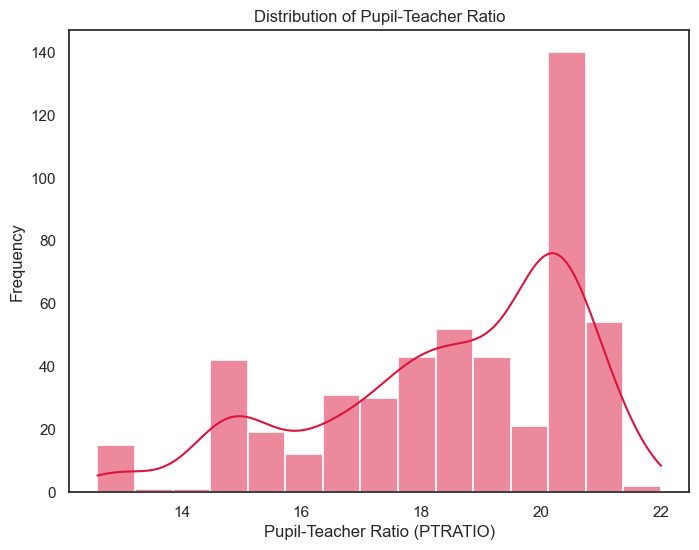

In [53]:
plt.figure(figsize=(8, 6))
sns.set_style("white") 

sns.histplot(
    x=boston_df['PTRATIO'],
    bins=15, 
    kde=True,
    color='crimson',
    edgecolor='white',  
    linewidth=1.2
)
plt.title("Distribution of Pupil-Teacher Ratio")
plt.xlabel("Pupil-Teacher Ratio (PTRATIO)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

In [59]:
#Use Levene’s test to check if the variances of MEDV for homes bounded by the Charles River (CHAS = 1) and those not bounded (CHAS = 0) are equal.

from scipy.stats import levene

#Setting Up The Hypothesis First:----------------------------------------
print("Hypothesis:")
print("H0: The variances of MEDV for both groups are equal.")
print("H1: The variances of MEDV for both groups are not equal.")


group1 = boston_df[boston_df['CHAS'] == 1]['MEDV']
group2 = boston_df[boston_df['CHAS'] == 0]['MEDV']
stat, p_value = levene(group1, group2)

print("-" * 30)

print(f"Levene Test Statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

print("-" * 30)

if p_value < 0.05:
    print("Result: We Reject the null hypothesis.The house prices (MEDV) for homes near the river have a much wider (or narrower) spread than those away from the river.")
else:
    print("Result: We Fail to reject the null hypothesis.The volatility of house prices is roughly the same regardless of the river. ")

Hypothesis:
H0: The variances of MEDV for both groups are equal.
H1: The variances of MEDV for both groups are not equal.
------------------------------
Levene Test Statistic: 4.5903
p-value: 0.0326
------------------------------
Result: We Reject the null hypothesis.The house prices (MEDV) for homes near the river have a much wider (or narrower) spread than those away from the river.


In [60]:
#Perform a T-test to determine if there is a significant difference in MEDV between homes bounded and not bounded by the Charles River.


from scipy.stats import ttest_ind
#Setting Up The Hypothesis First:----------------------------------------
print("Hypothesis:")
print("H0: There is no significant difference in median home values (MEDV) between homes near the Charles River and those that are not.")
print("H1: There is a significant difference in MEDV between the two groups.")
print("-" * 30)

table1 = boston_df[boston_df['CHAS'] == 1]['MEDV']
table2 = boston_df[boston_df['CHAS'] == 0]['MEDV']
t_stat, p_val = ttest_ind(table1, table2)

#Outcome goes here : --------
print(f"T-Statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: We Reject the null hypothesis. Being near the water is a statistically significant factor in property value .")
else:
    print("Result: WE Fail to reject the null hypothesis.We don't have enough evidence to say the river changes home values; treat them as if they are the same.")

Hypothesis:
H0: There is no significant difference in median home values (MEDV) between homes near the Charles River and those that are not.
H1: There is a significant difference in MEDV between the two groups.
------------------------------
T-Statistic: 3.9964
p-value: 0.0001
Result: We Reject the null hypothesis. Being near the water is a statistically significant factor in property value .


In [61]:
#Conduct an ANOVA test to compare MEDV among the three AGE groups created earlier.

from scipy.stats import f_oneway
print("Hypothesis:")
print("H0: The mean MEDV is the same across all three age groups.")
print("H1: At least one age group's mean MEDV is significantly different.")
print("-" * 30)

young = boston_df[x == 'Young']['MEDV']
mid   = boston_df[x == 'Mid']['MEDV']
old   = boston_df[x == 'Old']['MEDV']
f_stat, p_val = f_oneway(young, mid, old)

# OUTPUT
print(f"F-Statistic: {f_stat:.4f}")
print(f"p-value: {p_val:.4f}")

if p_val < 0.05:
    print("We Result: We Reject the null hypothesis.We shouldn't treat all houses as one big pool. The age of the house significantly impacts its value.")
else:
    print("We Result: We Fail to reject the null hypothesis.There is no evidence that the age of the home influences the price.")

Hypothesis:
H0: The mean MEDV is the same across all three age groups.
H1: At least one age group's mean MEDV is significantly different.
------------------------------
F-Statistic: 36.4350
p-value: 0.0000
We Result: We Reject the null hypothesis.We shouldn't treat all houses as one big pool. The age of the house significantly impacts its value.


In [57]:
#Perform a Pearson correlation test to assess the relationship between NOX and INDUS.
from scipy.stats import pearsonr
print("Hypothesis:")
print("H0: There is no linear relationship between NOX and INDUS (Correlation = 0).")
print("H1: There is a significant linear relationship between NOX and INDUS.")
print("-" * 30)

corr, p_val = pearsonr(boston_df['NOX'], boston_df['INDUS'])

#Result
print(f"Pearson Correlation Coefficient: {corr:.4f}")
print(f"p-value: {p_val:.4f}")

#Decision: 
if p_val < 0.05:
    sig_result = "statistically significant"
else:
    sig_result = "not statistically significant"

#Decision
if abs(corr) >= 0.7:
    strength = "strong"
elif abs(corr) >= 0.3:
    strength = "moderate"
else:
    strength = "weak"

direction = "positive" if corr > 0 else "negative"

#Final Verdict from the code : 
print(f"Result: The relationship is {sig_result} with a {strength} {direction} correlation.")

Hypothesis:
H0: There is no linear relationship between NOX and INDUS (Correlation = 0).
H1: There is a significant linear relationship between NOX and INDUS.
------------------------------
Pearson Correlation Coefficient: 0.7637
p-value: 0.0000
Result: The relationship is statistically significant with a strong positive correlation.


In [58]:
#Fit a simple linear regression model to evaluate the impact of DIS (distance to employment centres) on MEDV. Report and interpret the regression results.
import statsmodels.api as sm
X = boston_df['DIS']      
y = boston_df['MEDV']   

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

intercept = model.params[0]
slope = model.params[1]
p_slope = model.pvalues[1]
r_squared = model.rsquared

print(f"R-squared: {r_squared:.4f}")
print(f"Coefficient for DIS: {slope:.4f}")
print(f"P-value for DIS: {p_slope:.4f}")


                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           1.21e-08
Time:                        23:01:10   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0

C:\Users\USER\AppData\Local\Temp\ipykernel_18456\2657035312.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = model.params[0]
C:\Users\USER\AppData\Local\Temp\ipykernel_18456\2657035312.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = model.params[1]
C:\Users\USER\AppData\Local\Temp\ipykernel_18456\2657035312.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_slope = model.pvalues[1]


The regression analysis shows a statistically significant positive relationship between distance to employment centers (DIS) and home values (MEDV). Specifically for every one-unit increase in distance the median home value is expected to increase by approximately 1.09 units ($1,091). With a p-value of 0.000 we reject the null hypothesis and suggest that in this dataset properties further from major business hubs command higher market prices.